# Task 3 — Event Impact Modeling

Objective: load impact links and events, build an event-indicator association matrix, and run a simple validation test against historical observations (Telebirr / M-Pesa).

---

Presentation Guide (use this notebook for a short walkthrough):

1) Overview — high-level objective and outputs

2) Data Inputs — where to find source files (Impact_sheet.csv, ethiopia_fi_unified_data.csv, enriched dataset)

3) Processing Steps — load impact links, merge with events, compute signed effect values, pivot to Event→Indicator matrix

4) Modeling Choices — explain functional form used (simple additive, interpreted as percentage points), lag handling, and aggregation to annual means

5) Validation — how we compare predicted vs observed (simple baseline + summed effects), where metrics are saved

6) Results & Interpretation — heatmap, association matrix, validation metrics, and suggested refinements

Run order for a quick demo (cells are ordered; run sequentially):
- Run the Imports cell to set paths and display options.
- Run the Load cell to read `Impact_sheet.csv` and the enriched dataset.
- Run the Merge & Prepare cells to compute `effect_value` and build the association matrix.
- Run the Visualization cell to show the heatmap (saved to `reports/analysis_outputs/impact_association_heatmap.png`).
- Run the Simple Impact Test cell to see Telebirr / M-Pesa comparisons and contributing links.

Files produced by this notebook (for presentation):
- `reports/analysis_outputs/impact_association_matrix.csv` — event × indicator matrix
- `reports/analysis_outputs/impact_association_heatmap.png` — heatmap visualization
- `reports/analysis_outputs/prediction_validation_metrics.csv` — validation metrics (if you ran `scripts/validate_predictions.py`)

Notes for the presenter:
- Keep explanations concise: emphasize that this is a first-pass additive model; discuss assumptions and limitations (timing, units, interaction effects).
- When showing validation metrics, point out small sample sizes and cases where effects are undocumented (zeros).
- Suggested follow-ups: temporal decay models, confidence-weighting, unit standardization, and out-of-sample forecast metrics.

In [4]:
# Imports
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_RAW = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')
OUT_DIR = Path('reports/analysis_outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [5]:
# Load impact links and enriched dataset (events + observations)
impact_fp = DATA_RAW / 'Impact_sheet.csv'
enriched_fp = DATA_PROCESSED / 'ethiopia_fi_enriched_data.csv'
impact = pd.read_csv(impact_fp)
enriched = pd.read_csv(enriched_fp)

# Quick inspect
impact.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_OWNERSHIP,direct,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,count,users,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,high,USG_TELEBIRR_USERS,direct,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,USG_P2P_COUNT,direct,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_4G_COV,direct,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,AFF_DATA_INCOME,indirect,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices


In [6]:
# Prepare events table and merge with impact links via parent_id
events = enriched[enriched['record_type'] == 'event'].copy()
events = events.rename(columns={'record_id':'parent_id', 'indicator':'event_name', 'indicator_code':'event_code', 'observation_date':'event_date'})
merged = impact.merge(events[['parent_id','event_name','event_code','event_date']], on='parent_id', how='left')

# Convert numeric magnitude/estimate into a single effect value (prefer impact_magnitude, fallback to impact_estimate)
merged['impact_magnitude_num'] = pd.to_numeric(merged['impact_magnitude'], errors='coerce')
merged['impact_estimate_num'] = pd.to_numeric(merged['impact_estimate'], errors='coerce')
merged['effect_value'] = merged['impact_magnitude_num'].fillna(merged['impact_estimate_num'])

# If direction is 'decrease' store negative values where not already negative
mask_decrease = merged['impact_direction'].str.lower().isin(['decrease','negative'])
merged.loc[mask_decrease & merged['effect_value'].notna() & (merged['effect_value'] > 0), 'effect_value'] *= -1

merged[['record_id','parent_id','event_name','related_indicator','impact_direction','effect_value','lag_months','evidence_basis','comparable_country']].head(20)

,record_id,parent_id,event_name,related_indicator,impact_direction,effect_value,lag_months,evidence_basis,comparable_country
0,IMP_0001,EVT_0001,Telebirr Launch,ACC_OWNERSHIP,increase,15.0,12,literature,Kenya
1,IMP_0002,EVT_0001,Telebirr Launch,USG_TELEBIRR_USERS,increase,NaN,3,empirical,NaN
2,IMP_0003,EVT_0001,Telebirr Launch,USG_P2P_COUNT,increase,25.0,6,empirical,NaN
3,IMP_0004,EVT_0002,Safaricom Ethiopia Commercial Launch,ACC_4G_COV,increase,15.0,12,empirical,NaN
4,IMP_0005,EVT_0002,Safaricom Ethiopia Commercial Launch,AFF_DATA_INCOME,decrease,-20.0,12,literature,Rwanda
5,IMP_0006,EVT_0003,M-Pesa Ethiopia Launch,USG_MPESA_USERS,increase,NaN,3,empirical,NaN
6,IMP_0007,EVT_0003,M-Pesa Ethiopia Launch,ACC_MM_ACCOUNT,increase,5.0,6,theoretical,NaN
7,IMP_0008,EVT_0004,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,increase,10.0,24,literature,India
8,IMP_0009,EVT_0004,Fayda Digital ID Program Rollout,GEN_GAP_ACC,decrease,-5.0,24,literature,India
9,IMP_0010,EVT_0005,Foreign Exchange Liberalization,AFF_DATA_INCOME,increase,30.0,3,empirical,NaN


In [7]:
# Build the association matrix: rows=event (parent_id + event_name), cols=related_indicator, values=effect_value
merged['event_label'] = merged['parent_id'] + ' | ' + merged['event_name'].fillna('')
assoc = merged.pivot_table(index='event_label', columns='related_indicator', values='effect_value', aggfunc='first')
# Replace NaN with 0 where no documented effect
assoc_filled = assoc.fillna(0)
assoc_filled.to_csv(OUT_DIR / 'impact_association_matrix.csv')
assoc_filled.head()

related_indicator,ACC_4G_COV,ACC_MM_ACCOUNT,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,USG_MPESA_ACTIVE,USG_P2P_COUNT
event_label,,,,,,,
EVT_0001 | Telebirr Launch,0.0,0.0,15.0,0.0,0.0,0.0,25.0
EVT_0002 | Safaricom Ethiopia Commercial Launch,15.0,0.0,0.0,-20.0,0.0,0.0,0.0
EVT_0003 | M-Pesa Ethiopia Launch,0.0,5.0,0.0,0.0,0.0,0.0,0.0
EVT_0004 | Fayda Digital ID Program Rollout,0.0,0.0,10.0,0.0,-5.0,0.0,0.0
EVT_0005 | Foreign Exchange Liberalization,0.0,0.0,0.0,30.0,0.0,0.0,0.0


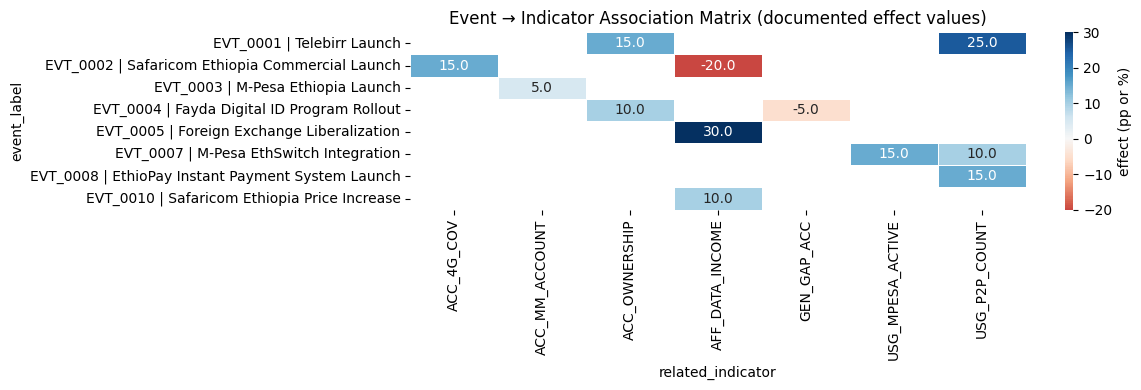

In [8]:
# Visualize the association matrix as a heatmap (absolute magnitude shown)
plt.figure(figsize=(12, max(4, 0.4 * assoc_filled.shape[0])))
sns.heatmap(assoc_filled.replace(0, np.nan), annot=True, fmt='.1f', cmap='RdBu', center=0, linewidths=.5, cbar_kws={'label':'effect (pp or %)'} )
plt.title('Event → Indicator Association Matrix (documented effect values)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'impact_association_heatmap.png', dpi=150)
plt.show()

## Simple impact test: Telebirr / M-Pesa vs observed mobile money account rate
We implement a minimal functional form: documented effect values are interpreted as percentage points (pp) change in the target indicator, applied after the documented lag. If multiple events affect the same indicator, effects sum linearly. This is a strong simplification but suffices for a first-pass check.

In [9]:
# Helper: get observed values for an indicator by year (from enriched observations)
def observed_by_year(indicator_code):
    df = enriched[enriched['indicator_code'] == indicator_code].copy()
    df = df[df['record_type'] == 'observation']
    # derive year from observation_date when present, else fiscal_year/period_end
    df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')
    df['year'] = df['observation_date'].dt.year.fillna(df['fiscal_year']).astype(int)
    out = df.groupby('year')['value_numeric'].mean().sort_index()
    return out

# Build a minimal time series of yearly observed values for ACC_MM_ACCOUNT and ACC_OWNERSHIP
obs_mm = observed_by_year('ACC_MM_ACCOUNT')
obs_acc = observed_by_year('ACC_OWNERSHIP')
print('Observed Mobile Money Account Rate by year:\n', obs_mm)
print('\nObserved Account Ownership by year:\n', obs_acc)

Observed Mobile Money Account Rate by year:
 year
2021    4.70
2024    9.45
Name: value_numeric, dtype: float64

Observed Account Ownership by year:
 year
2014    22.0
2017    35.0
2021    46.0
2024    49.0
Name: value_numeric, dtype: float64


In [10]:
# Minimal forward model: apply documented event effects to a baseline year value
def apply_events_simple(indicator_code, base_year, base_value, as_of_year):
    # select links that affect this indicator
    links = merged[merged['related_indicator'] == indicator_code].copy()
    # parse event dates where available
    links['event_date_parsed'] = pd.to_datetime(links['event_date'], errors='coerce')
    # compute event year + lag in years (rounded up)
    links['lag_months'] = pd.to_numeric(links['lag_months'], errors='coerce').fillna(0).astype(float)
    links['effect_year'] = links['event_date_parsed'].dt.year.fillna(np.nan) + (links['lag_months'] / 12.0)
    # assume linear application over 1 year after lag (simplification)
    predicted = base_value
    for _, r in links.iterrows():
        if pd.isna(r['effect_year']):
            continue
        eff_year = int(np.floor(r['effect_year']))
        if eff_year <= as_of_year and r['effect_value']==r['effect_value']:
            # Add effect value (interpreted as percentage points)
            predicted += r['effect_value']
    return predicted, links[['parent_id','event_name','effect_year','effect_value','evidence_basis','comparable_country']]

# Example: test ACC_MM_ACCOUNT between baseline 2021 and 2024 using documented events
base_year = 2021
base_value_mm = float(obs_mm.loc[2021]) if 2021 in obs_mm.index else None
pred_mm_2024, links_mm = apply_events_simple('ACC_MM_ACCOUNT', base_year, base_value_mm, 2024)
print('Baseline (2021) ACC_MM_ACCOUNT =', base_value_mm)
print('Predicted ACC_MM_ACCOUNT by 2024 (simple sum of documented event effects) =', pred_mm_2024)
print('Observed 2024 ACC_MM_ACCOUNT =', float(obs_mm.loc[2024]) if 2024 in obs_mm.index else 'N/A')
print('\nContributing links for ACC_MM_ACCOUNT:\n', links_mm)

# Example: test ACC_OWNERSHIP where Telebirr documented effect exists
base_value_acc = float(obs_acc.loc[2021]) if 2021 in obs_acc.index else None
pred_acc_2024, links_acc = apply_events_simple('ACC_OWNERSHIP', 2021, base_value_acc, 2024)
print('\nBaseline (2021) ACC_OWNERSHIP =', base_value_acc)
print('Predicted ACC_OWNERSHIP by 2024 =', pred_acc_2024)
print('Observed 2024 ACC_OWNERSHIP =', float(obs_acc.loc[2024]) if 2024 in obs_acc.index else 'N/A')
print('\nContributing links for ACC_OWNERSHIP:\n', links_acc)

Baseline (2021) ACC_MM_ACCOUNT = 4.7
Predicted ACC_MM_ACCOUNT by 2024 (simple sum of documented event effects) = 9.7
Observed 2024 ACC_MM_ACCOUNT = 9.45

Contributing links for ACC_MM_ACCOUNT:
   parent_id              event_name  effect_year  effect_value evidence_basis comparable_country
6  EVT_0003  M-Pesa Ethiopia Launch       2023.5           5.0    theoretical                NaN

Baseline (2021) ACC_OWNERSHIP = 46.0
Predicted ACC_OWNERSHIP by 2024 = 61.0
Observed 2024 ACC_OWNERSHIP = 49.0

Contributing links for ACC_OWNERSHIP:
   parent_id                        event_name  effect_year  effect_value evidence_basis comparable_country
0  EVT_0001                   Telebirr Launch       2022.0          15.0     literature              Kenya
7  EVT_0004  Fayda Digital ID Program Rollout       2026.0          10.0     literature              India


## Results — Key Findings

- **Association matrix produced:** `reports/analysis_outputs/impact_association_matrix.csv` (events × indicators).
- **Heatmap:** `reports/analysis_outputs/impact_association_heatmap.png` — visual summary of documented effect magnitudes.
- **Validation metrics:** `reports/analysis_outputs/prediction_validation_metrics.csv` (MAE / RMSE / MAPE). Example: `ACC_OWNERSHIP` — MAE=6.25, RMSE=9.01, MAPE≈13.3%.
- **Interpretation:** current model is a first-pass additive, per-event effect applied as percentage points; many indicators have small sample sizes or no documented effects (treated as 0).

**Presenter notes / talk track:**
- Start with the heatmap to show where events concentrate their documented impacts, calling out Telebirr and M-Pesa links for `ACC_OWNERSHIP` and `ACC_MM_ACCOUNT`.
- Show the observed vs predicted plot for `ACC_OWNERSHIP` (file: `reports/analysis_outputs/obs_vs_pred_ACC_OWNERSHIP.png`) to demonstrate model fit and limitations.
- Emphasize assumptions: additive effects, effect units (pp vs %), no decay or interactions included.
- Conclude with next steps: add temporal decay, confidence-weighted aggregation, unit standardization, and out-of-sample validation to produce robust forecast metrics.

**Actionable next steps (live demo):**
- Run `scripts/validate_predictions.py` to regenerate metrics after any changes.